# Ranging and Ransac

We'll use the following imports:

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import linear_model

If you get an error from importing sklearn, then you will have to install it using:
conda install scikit-learn

For the exercise we will be using the data taken from a lidar by a robot in a hallway. The data is saved in `laser.csv` and we can import this in Python using numpy as such:

In [2]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 6/"
laser = np.genfromtxt(path + 'laser.csv', delimiter=',')

The file contains only a single rotation of the lidar. You can open the file in any text editor to get a look at the data. Each number in the file is the distance measured in meters. The lidar starts measuring at 135 degrees and ends at -135 degrees and it rotates the same amount between each measurement. 

## Exercise 3.1
Convert the data in the csv file to x and y coordinates in a Carthesian coordinate system and plot the result using matplotlib.

Hint: Use [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) instead of plt.plot in order to show every measurement as a point. 

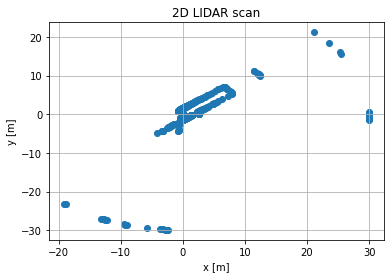

In [9]:
# Convert to x and y coordinates
# The LIDAR gives us Range (distance) data. We are told the Field of View is from 135 to -135 degrees.
# We create an array of angles corresponding to each measurement.
# np.linspace(start, stop, num): Generates 'num' evenly spaced samples.
# We multiply by pi/180 to convert Degrees to Radians (numpy trig functions expect radians).
angle = np.linspace(-135, 135, laser.shape[0]) * np.pi / 180

# Convert Polar coordinates (r, theta) to Cartesian (x, y)
# x = r * cos(theta)
# y = r * sin(theta)
x = laser * np.cos(angle)
y = laser * np.sin(angle)

plt.scatter(x, y)
plt.title('2D LIDAR scan')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid()

## Exercise 3.2

We would like to locate one of the walls in the dataset. To do so we will use [Ransac](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RANSACRegressor.html) to fine the best line fit in the noisy data. A Ransac regressor is initialized the following way using sklearn:

In [10]:
# RANSAC (Random Sample Consensus) is an iterative method to estimate parameters of a mathematical model.
# Unlike standard Linear Regression (OLS) which minimizes error on ALL points (including noise/outliers),
# RANSAC assumes that data is composed of "inliers" (points that fit the model) and "outliers" (noise).
# It randomly selects a subset of points, fits a model, and counts how many other points fit that model.
# The model with the most inliers wins.
ransac = linear_model.RANSACRegressor()

Now that we have our Ransac regressor we can fit it to a dataset (x,y):

In [11]:
# Fit data
# scikit-learn models expect the input X to be a 2D array (matrix) of shape (n_samples, n_features).
# Our 'x' is a 1D array, so we reshape it to (-1, 1) -> (N rows, 1 column).
ransac_fit = ransac.fit(x.reshape(-1, 1), y)

Finally, to get the fitted line we can use the predict function. As an argument this takes the x values in which the line will be predicted:

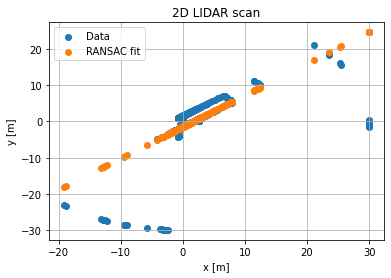

In [12]:
# Predict line
# We ask the model: "Given these X coordinates, what should the Y coordinates be if they lay perfectly on the line?"
ransac_pred = ransac.predict(x.reshape(-1, 1))

plt.scatter(x, y)
plt.scatter(x, ransac_pred)
plt.title('2D LIDAR scan')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend(['Data', 'RANSAC fit'])
plt.grid()

Plot the line on top of the scatterplot from before to see the fit.

## Exercise 3.3

To see which data points were used to make the line fit and which were deemed outliers, we can use the function ransac.inlier_mask_

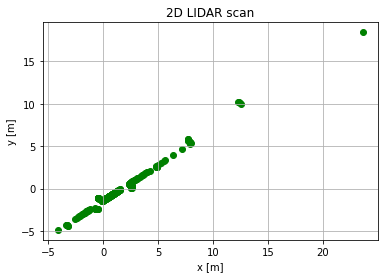

In [13]:
# ransac.inlier_mask_ is a boolean array (True/False).
# It is True for points that the algorithm decided belong to the wall, and False for outliers.
plt.scatter(x[ransac.inlier_mask_], y[ransac.inlier_mask_], color='green')
plt.title('2D LIDAR scan')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid()

Find the second hallway wall using another Ransac fit and plot it together with the data points and the first ransac fit.

Hint: Use the outliers from the first Ransac.

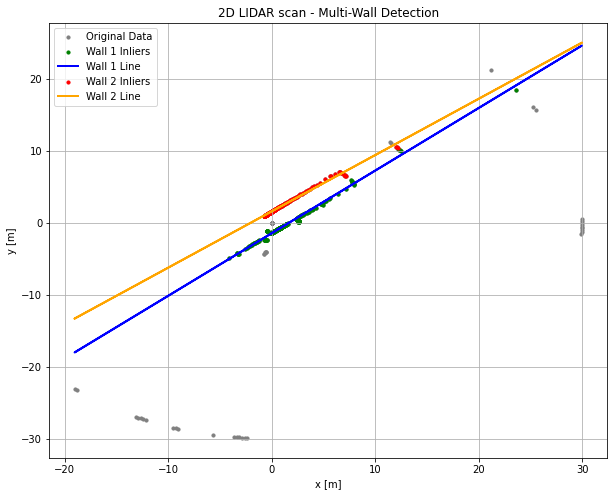

In [14]:
ransac2 = linear_model.RANSACRegressor()

# Find the second hallway wall
# 1. Identify the outliers from the first fit.
# np.logical_not inverts the boolean mask (True becomes False, False becomes True).
# So 'outlier_mask' is True for points that did NOT fit the first wall.
outlier_mask = np.logical_not(ransac.inlier_mask_)

# 2. Extract the data points corresponding to these outliers.
# This effectively removes the first wall from our dataset so we can find the next structure.
x_outliers = x[outlier_mask]
y_outliers = y[outlier_mask]

# 3. Fit the second RANSAC model to the remaining points.
ransac2.fit(x_outliers.reshape(-1, 1), y_outliers)

# 4. Predict the line for the second wall
ransac2_pred = ransac2.predict(x_outliers.reshape(-1, 1))

# Plotting everything together
plt.figure(figsize=(10, 8))

# Plot all original data
plt.scatter(x, y, color='gray', label='Original Data', s=10)

# Plot the first wall (Inliers of Model 1)
plt.scatter(x[ransac.inlier_mask_], y[ransac.inlier_mask_], color='green', label='Wall 1 Inliers', s=10)
plt.plot(x, ransac_pred, color='blue', linewidth=2, label='Wall 1 Line')

# Plot the second wall (Inliers of Model 2, which are a subset of the original outliers)
# Note: ransac2.inlier_mask_ is relative to x_outliers, not the original x!
plt.scatter(x_outliers[ransac2.inlier_mask_], y_outliers[ransac2.inlier_mask_], color='red', label='Wall 2 Inliers', s=10)
plt.plot(x_outliers, ransac2_pred, color='orange', linewidth=2, label='Wall 2 Line')

plt.title('2D LIDAR scan - Multi-Wall Detection')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.legend()
plt.grid()